In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob2
import os
import glob
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


pd.set_option('display.max_rows', None)

In [ ]:

# ---------- load & reshape ----------
csv_path = "/Volumes/project/3025011.02/for_carla/model_fit_comparison.csv"
df = pd.read_csv(csv_path)

# if you don't have a subject column, create one
if "subject" not in df.columns:
    df["subject"] = df.index + 1

# melt wide -> long
long = df.melt(
    id_vars="subject",
    value_vars=["model0_AIC","model1_AIC","model2_AIC","model3_AIC","model4_AIC"],
    var_name="model_key", value_name="AIC"
)

label_map = {
    "model0_AIC":"NM",
    "model1_AIC":"RW",
    "model2_AIC":"2LR-RW",
    "model3_AIC":"HM",
    "model4_AIC":"2W-HM"
}
order = ["NM","RW","2LR-RW","HM","2W-HM"]
long["model"] = pd.Categorical(long["model_key"].map(label_map), categories=order, ordered=True)

# ---------- choose an outlier cutoff ----------
# Use 2000 by default; change if your data suggest otherwise
CUTOFF = 2000

# Which rows are extreme?
long["is_extreme"] = long["AIC"] > CUTOFF
extreme_subjects = sorted(long.loc[long["is_extreme"], "subject"].unique())
print(f"Extreme subjects (AIC > {CUTOFF} in at least one model): {extreme_subjects}")

# ---------- helper: connect per-subject lines ----------
def connect_lines(ax, data):
    for sid, sub in data.sort_values("model").groupby("subject"):
        ax.plot(sub["model"].cat.codes, sub["AIC"],
                color="grey", alpha=0.35, linewidth=0.7, zorder=0)

# =========================================================
# 1) TRIMMED PLOT (<= cutoff), highlight “extreme” subjects in red
# =========================================================
trim = long[long["AIC"] <= CUTOFF].copy()

plt.figure(figsize=(9,4))
ax = sns.boxplot(data=trim, x="model", y="AIC",
                 order=order, width=0.6, showfliers=False,
                 color="tomato", saturation=0.5)
connect_lines(ax, trim)

# all points (non-extreme) in black
sns.stripplot(data=trim[~trim["subject"].isin(extreme_subjects)],
              x="model", y="AIC", order=order,
              color="black", size=4, jitter=0.08, zorder=1)

# highlight subjects that were extreme (anywhere) in red even in trimmed view
sns.stripplot(data=trim[trim["subject"].isin(extreme_subjects)],
              x="model", y="AIC", order=order,
              color="red", size=5, jitter=0.08, zorder=2)

plt.ylabel("AIC")
plt.xlabel("")
sns.despine()
plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig("figures/AIC_boxlines_trimmed.png", dpi=200)
plt.show()

# =========================================================
# 2) FULL PLOT (all data), log y-scale
# =========================================================
plt.figure(figsize=(9,4))
ax = sns.boxplot(data=long, x="model", y="AIC",
                 order=order, width=0.6, showfliers=False,
                 color="tomato", saturation=0.5)
connect_lines(ax, long)

# points: extreme in red, others in black
sns.stripplot(data=long[~long["is_extreme"]],
              x="model", y="AIC", order=order,
              color="black", size=4, jitter=0.08, zorder=1)
sns.stripplot(data=long[long["is_extreme"]],
              x="model", y="AIC", order=order,
              color="red", size=5, jitter=0.08, zorder=2)

plt.yscale("log")
plt.ylabel("AIC (log scale)")
plt.xlabel("")
sns.despine()
plt.tight_layout()
plt.savefig("figures/AIC_boxlines_full_log.png", dpi=200)
plt.show()


In [ ]:
# ---------- load & reshape ----------
csv_path = "/Volumes/project/3025011.02/for_carla/model_fit_comparison.csv"
df = pd.read_csv(csv_path)

# if you don't have a subject column, create one
if "subject" not in df.columns:
    df["subject"] = df.index + 1

# melt wide -> long
long = df.melt(
    id_vars="subject",
    value_vars=["model0_BIC","model1_BIC","model2_BIC","model3_BIC","model4_BIC"],
    var_name="model_key", value_name="BIC"
)

label_map = {
    "model0_BIC":"NM",
    "model1_BIC":"RW",
    "model2_BIC":"2LR-RW",
    "model3_BIC":"HM",
    "model4_BIC":"2W-HM"
}
order = ["NM","RW","2LR-RW","HM","2W-HM"]
long["model"] = pd.Categorical(long["model_key"].map(label_map), categories=order, ordered=True)

# ---------- choose an outlier cutoff ----------
# Use 2000 by default; change if your data suggest otherwise
CUTOFF = 2000

# Which rows are extreme?
long["is_extreme"] = long["BIC"] > CUTOFF
extreme_subjects = sorted(long.loc[long["is_extreme"], "subject"].unique())
print(f"Extreme subjects (BIC > {CUTOFF} in at least one model): {extreme_subjects}")

# ---------- helper: connect per-subject lines ----------
def connect_lines(ax, data):
    for sid, sub in data.sort_values("model").groupby("subject"):
        ax.plot(sub["model"].cat.codes, sub["BIC"],
                color="grey", alpha=0.35, linewidth=0.7, zorder=0)

# =========================================================
# 1) TRIMMED PLOT (<= cutoff), highlight “extreme” subjects in red
# =========================================================
trim = long[long["BIC"] <= CUTOFF].copy()

plt.figure(figsize=(9,4))
ax = sns.boxplot(data=trim, x="model", y="BIC",
                 order=order, width=0.6, showfliers=False,
                 color="tomato", saturation=0.5)
connect_lines(ax, trim)

# all points (non-extreme) in black
sns.stripplot(data=trim[~trim["subject"].isin(extreme_subjects)],
              x="model", y="BIC", order=order,
              color="black", size=4, jitter=0.08, zorder=1)

# highlight subjects that were extreme (anywhere) in red even in trimmed view
sns.stripplot(data=trim[trim["subject"].isin(extreme_subjects)],
              x="model", y="BIC", order=order,
              color="red", size=5, jitter=0.08, zorder=2)

plt.ylabel("BIC")
plt.xlabel("")
sns.despine()
plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig("figures/BIC_boxlines_trimmed.png", dpi=200)
plt.show()

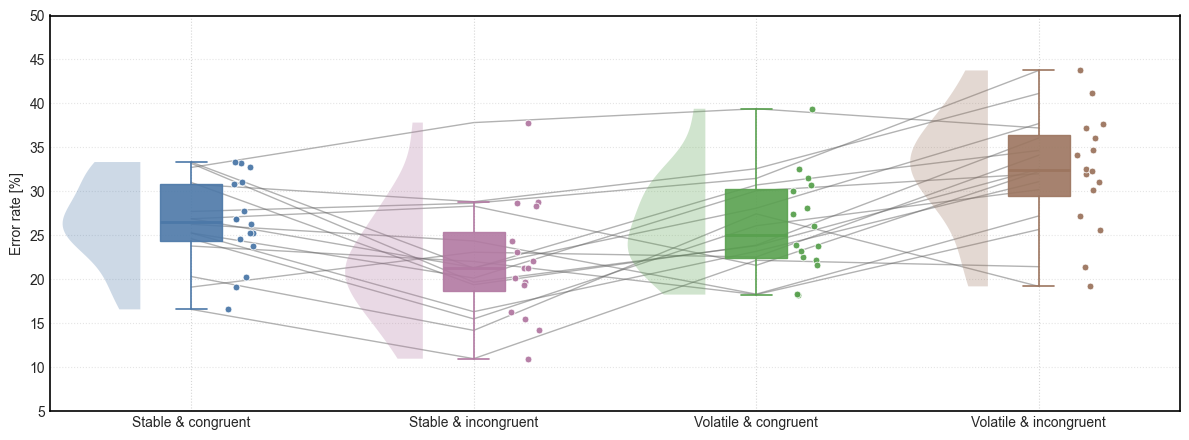

In [25]:
#This is the not innate congruency

# -*- coding: utf-8 -*-
# Bigger half-violin (left) + centered box + right jitter per condition
# Plotting ERROR RATE with new congruency definition


CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# --- redefine congruency based on valence × response ---
df["valence"]  = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()

df["congruency"] = np.where(
    ((df["valence"] == "happy") & (df["response"] == "down")) |
    ((df["valence"] == "angry") & (df["response"] == "up")),
    "congruent",
    "incongruent"
)

# volatility cleanup
df["volatility"] = (
    df["volatility"].astype(str).str.strip().str.lower()
      .map({"stable":"stable","volatile":"volatile",
            "s":"stable","v":"volatile","0":"stable","1":"volatile"})
)

# accuracy: prefer objectively_correct, fall back to *_boolean
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# 🔹 compute error rate
df["error_rate"] = 1 - df["accuracy"]

df["condition"] = df["volatility"].str.title() + " & " + df["congruency"]
order = ["Stable & congruent","Stable & incongruent","Volatile & congruent","Volatile & incongruent"]

# per-participant means (%)
pp = (df.groupby(["participant","condition"])["error_rate"].mean().mul(100).reset_index())
wide = pp.pivot(index="participant", columns="condition", values="error_rate").reindex(columns=order)

# -------- plotting (bigger elements, still separated) --------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 4.5))


x = np.arange(len(order))
violin_pos = x - 0.18    # left
box_pos    = x           # center
scatter_pos= x + 0.18    # right

data = [wide[c].dropna().values for c in order]
nonempty = [len(a) > 0 for a in data]

# supervisor-like palette
colors = {
    "Stable & congruent":     "#4C78A8",  # blue
    "Stable & incongruent":   "#B279A2",  # magenta
    "Volatile & congruent":   "#59A14F",  # green
    "Volatile & incongruent": "#9C755F",  # brown
}
cols = [colors[c] for c in order]

# --- bigger half violins (left) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    v = ax.violinplot([vals], positions=[violin_pos[i]], widths=0.55,
                      showextrema=False, side='low')
    body = v["bodies"][0]
    body.set_facecolor(cols[i]); body.set_edgecolor("none"); body.set_alpha(0.28); body.set_zorder(1)

# --- wider boxes (center) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    bx = ax.boxplot([vals], positions=[box_pos[i]], widths=0.22,
                    patch_artist=True, showfliers=False)
    # color all parts
    for artist in bx["boxes"]:
        artist.set_facecolor(cols[i]); artist.set_alpha(0.90); artist.set_edgecolor(cols[i])
    for part in ("whiskers","caps","medians"):
        for artist in bx[part]:
            artist.set_color(cols[i])
            artist.set_linewidth(1.2 if part != "medians" else 2.0)

# --- jittered participant means (right) ---
rng = np.random.default_rng(7)
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    jitter = (rng.random(len(vals)) - 0.5) * 0.10
    ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,
               s=24, alpha=0.95, c=cols[i], edgecolors="white", linewidths=0.6, zorder=3)

# --- within-subject lines (behind) ---
for _, row in wide.iterrows():
    y = row.values.astype(float)
    xs = x[~np.isnan(y)]
    ys = y[~np.isnan(y)]
    if len(xs) >= 2:
        #ax.plot(xs, ys, linewidth=0.6, alpha=0.20, color="#c9c9c9", zorder=0)
        # within-subject lines (behind)
        ax.plot(xs, ys, linewidth=1.0, alpha=0.5, color="#666666", zorder=0)


# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Error rate [%]")   # 🔹 updated label
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)
# Stronger gridlines
ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.8)  # darker gray
ax.grid(axis="x", linestyle=":", color="#bbbbbb", alpha=0.6)  # optional x grid

vals = np.concatenate([a for a in data if len(a)>0]) if any(nonempty) else np.array([0,100])
lo = max(0, np.floor(vals.min()/5)*5 - 5)
hi = min(100, np.ceil(vals.max()/5)*5 + 5)
if lo >= hi: lo, hi = 0, 100
ax.set_ylim(lo, hi)
ax.grid(axis="y", linestyle=":", alpha=0.25)
ax.margins(x=0.02)
fig.tight_layout()
# fig.savefig("half_violin_box_jitter_errorrate.png", dpi=220)
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/hypothesis1_responsecongruency.pdf", dpi=220)
plt.show()

/var/folders/pf/qmvpxd8n4fs_3kydh8z2_yww0000gn/T/ipykernel_53491/3177962367.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


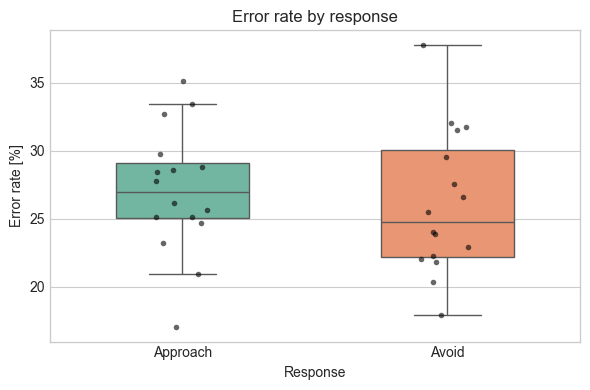

In [25]:
CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# --- load & prep ---
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

df["valence"]  = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()

# --- define accuracy ---
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# --- error rate ---
df["error_rate"] = 1 - df["accuracy"]

# --- per-participant means (%), now by RESPONSE ---
pp = (df.groupby(["participant","response"])["error_rate"]
        .mean()
        .mul(100)
        .reset_index())

# (Optional) map response labels to nicer names
pp["response"] = pp["response"].map({
    "down": "Approach",
    "up": "Avoid"
}).fillna(pp["response"])

# --- plot ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(
    data=pp, x="response", y="error_rate", ax=ax,
    width=0.5, fliersize=0, palette="Set2"
)
sns.stripplot(
    data=pp, x="response", y="error_rate", ax=ax,
    color="black", alpha=0.6, jitter=True, size=4
)

ax.set_ylabel("Error rate [%]")
ax.set_xlabel("Response")
ax.set_title("Error rate by response")

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/justresponse&errorrate.pdf", dpi=220, facecolor="white")
plt.show()

/var/folders/pf/qmvpxd8n4fs_3kydh8z2_yww0000gn/T/ipykernel_46701/3993895695.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


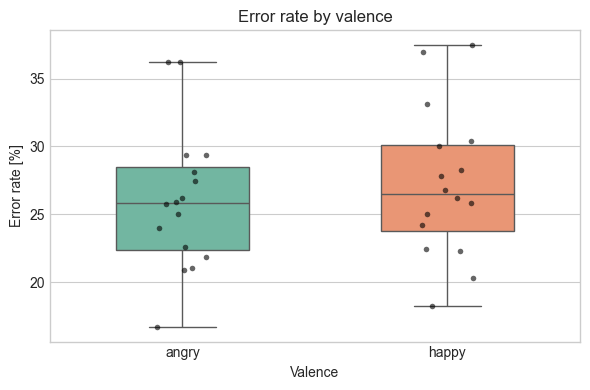

In [30]:
CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# --- load & prep ---
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

df["valence"]  = df["valence"].astype(str).str.strip().str.lower()

# --- define accuracy ---
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# --- error rate ---
df["error_rate"] = 1 - df["accuracy"]

# --- per-participant means (%), now by RESPONSE ---
pp = (df.groupby(["participant","valence"])["error_rate"]
        .mean()
        .mul(100)
        .reset_index())

# --- plot ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(6,4))

sns.boxplot(
    data=pp, x="valence", y="error_rate", ax=ax,
    width=0.5, fliersize=0, palette="Set2"
)
sns.stripplot(
    data=pp, x="valence", y="error_rate", ax=ax,
    color="black", alpha=0.6, jitter=True, size=4
)

ax.set_ylabel("Error rate [%]")
ax.set_xlabel("Valence")
ax.set_title("Error rate by valence")

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/valence&errorrate.pdf", dpi=220, facecolor="white")
plt.show()

Plotting order: ['Approach Angry', 'Avoid Angry', 'Approach Happy', 'Avoid Happy']


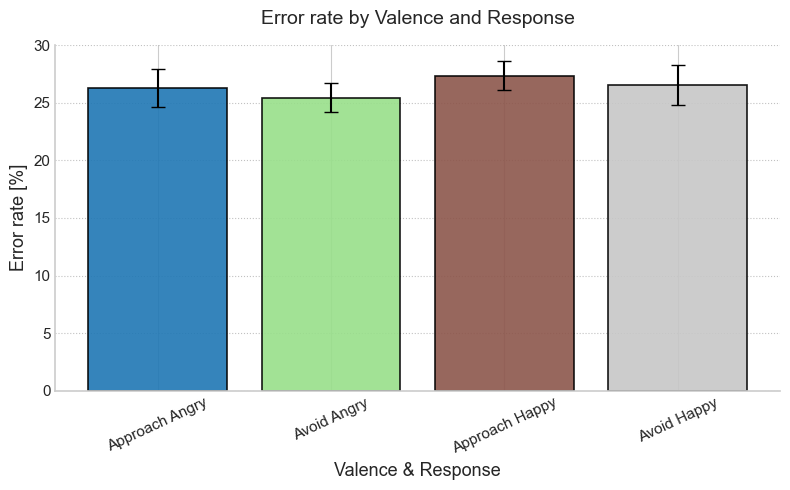

/var/folders/pf/qmvpxd8n4fs_3kydh8z2_yww0000gn/T/ipykernel_53491/2261852195.py:153: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,


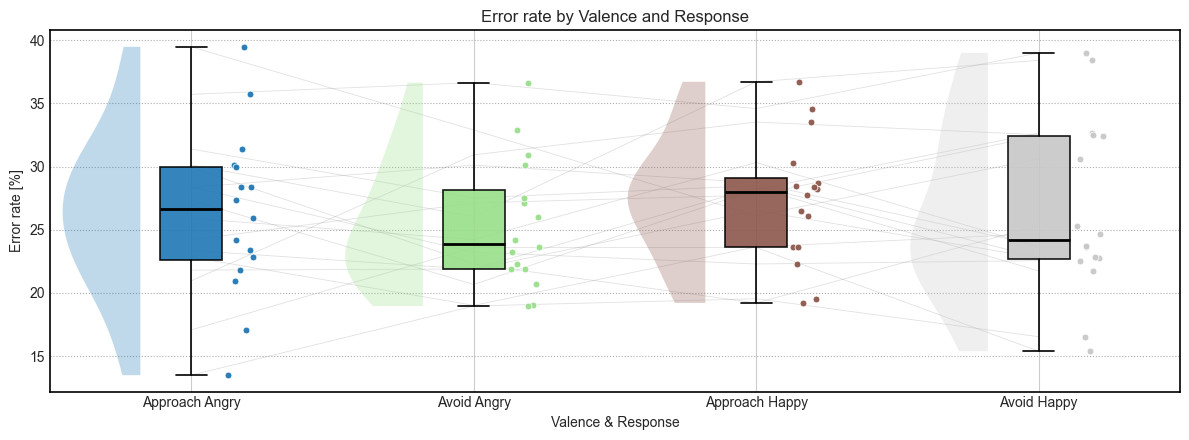

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()

# accuracy: prefer objectively_correct, fall back to *_boolean
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# compute error rate
df["error_rate"] = 1 - df["accuracy"]

# define condition labels
def make_label(row):
    resp = str(row["response"]).lower()
    val  = str(row["valence"]).lower()

    if resp.startswith("down"):
        act = "Approach"
    elif resp.startswith("up"):
        act = "Avoid"
    else:
        act = "Other"

    return f"{act} {val.capitalize()}"

df["condition"] = df.apply(make_label, axis=1)

# --- determine order dynamically ---
unique_conditions = df["condition"].unique().tolist()
preferred_order = [
    "Approach Angry", "Avoid Angry",
    "Approach Happy", "Avoid Happy"
]
order = [c for c in preferred_order if c in unique_conditions] + \
        [c for c in unique_conditions if c not in preferred_order]
print("Plotting order:", order)

# per-participant means (% error)
pp = (df.groupby(["participant", "condition"])["error_rate"]
        .mean().mul(100).reset_index())
wide = pp.pivot(index="participant", columns="condition", values="error_rate").reindex(columns=order)

# ===========================
# -------- BAR PLOT ---------
# ===========================
fig, ax = plt.subplots(figsize=(8, 5))

# compute group mean + SEM
means = wide.mean(axis=0, skipna=True)
sems  = wide.sem(axis=0, skipna=True)

# palette
base_colors = {
    "Approach happy": "#4C78A8",   # blue
    "Avoid happy":    "#B279A2",   # magenta
    "Approach angry": "#59A14F",   # green
    "Avoid angry":    "#9C755F",   # brown
}
cmap = plt.get_cmap("tab20")
cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

# plot bars with black outlines
ax.bar(order, means, yerr=sems,
       color=cols, capsize=5, alpha=0.9,
       edgecolor="black", linewidth=1.2)

# cosmetics
ax.set_ylabel("Error rate [%]", fontsize=13)
ax.set_xlabel("Valence & Response", fontsize=13)
ax.set_title("Error rate by Valence and Response", fontsize=14, pad=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.tick_params(axis="x", labelrotation=25, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_valence_response_bar.pdf", dpi=300, facecolor="white")
plt.show()

# ===============================
# --- VIOLIN + BOX + SCATTER ----
# ===============================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 4.5))

x = np.arange(len(order))
violin_pos  = x - 0.18
box_pos     = x
scatter_pos = x + 0.18

data = [wide[c].dropna().values for c in order]
nonempty = [len(a) > 0 for a in data]

# palette (fallback if condition not in dict)
cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

# --- half violins (left) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    v = ax.violinplot([vals], positions=[violin_pos[i]], widths=0.55,
                      showextrema=False, side='low')  # <-- keep half violins
    body = v["bodies"][0]
    body.set_facecolor(cols[i])
    body.set_edgecolor("none")
    body.set_alpha(0.28)
    body.set_zorder(1)

# --- wider boxes (center) with black outlines ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    bx = ax.boxplot([vals], positions=[box_pos[i]], widths=0.22,
                    patch_artist=True, showfliers=False)
    for artist in bx["boxes"]:
        artist.set_facecolor(cols[i])
        artist.set_alpha(0.90)
        artist.set_edgecolor("black")   # black outline
        artist.set_linewidth(1.2)
    for part in ("whiskers", "caps"):
        for artist in bx[part]:
            artist.set_color("black")   # black whiskers/caps
            artist.set_linewidth(1.2)
    for artist in bx["medians"]:
        artist.set_color("black")       # black median
        artist.set_linewidth(2.0)

# --- jittered participant means (right) ---
rng = np.random.default_rng(7)
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    jitter = (rng.random(len(vals)) - 0.5) * 0.10
    ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,
               s=24, alpha=0.95, c=cols[i], edgecolors="white", linewidths=0.6, zorder=3)

# --- within-subject lines ---
for _, row in wide.iterrows():
    y = row.values.astype(float)
    xs = x[~np.isnan(y)]
    ys = y[~np.isnan(y)]
    if len(xs) >= 2:
        ax.plot(xs, ys, linewidth=0.6, alpha=0.25, color="#888888", zorder=0)

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Error rate [%]")
ax.set_xlabel("Valence & Response")
ax.set_title("Error rate by Valence and Response")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)

ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.8)

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_valence_response.pdf", dpi=220, facecolor="white")
plt.show()


Plotting order: ['Approach Angry', 'Avoid Angry', 'Approach Happy', 'Avoid Happy']


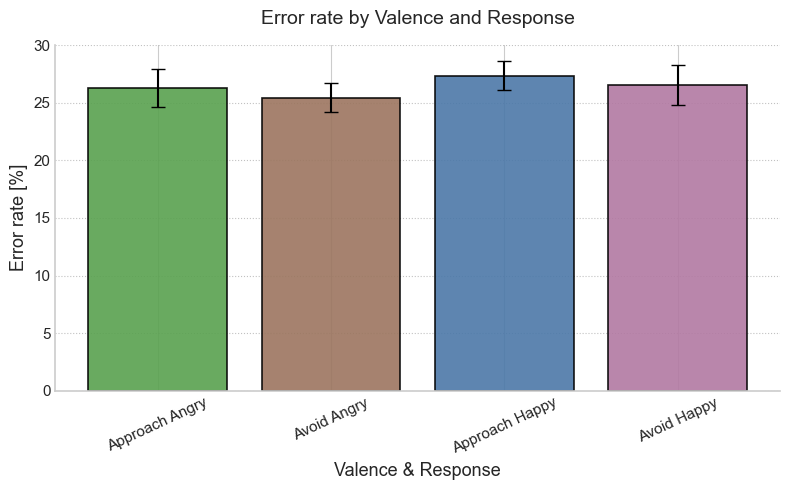

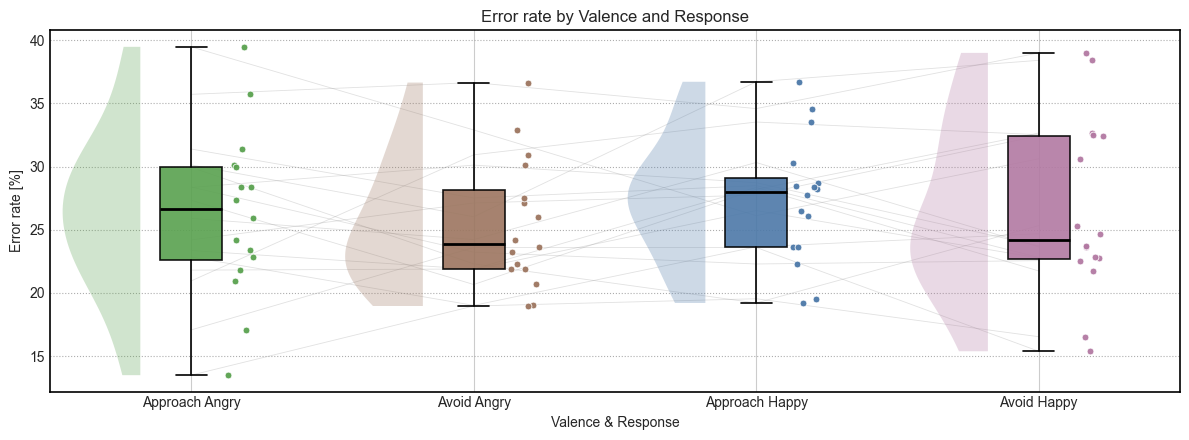

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()

# accuracy: prefer objectively_correct, fall back to *_boolean
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# compute error rate
df["error_rate"] = 1 - df["accuracy"]

# define condition labels (kept as you had them)
def make_label(row):
    resp = str(row["response"]).lower()
    val  = str(row["valence"]).lower()

    if resp.startswith("down"):
        act = "Approach"
    elif resp.startswith("up"):
        act = "Avoid"
    else:
        act = "Other"

    return f"{act} {val.capitalize()}"

df["condition"] = df.apply(make_label, axis=1)

# --- determine order dynamically ---
unique_conditions = df["condition"].unique().tolist()

# IMPORTANT: match the exact capitalization produced by make_label()
preferred_order = [
    "Approach Angry", "Avoid Angry",
    "Approach Happy", "Avoid Happy"
]

order = [c for c in preferred_order if c in unique_conditions] + \
        [c for c in unique_conditions if c not in preferred_order]
print("Plotting order:", order)

# per-participant means (% error)
pp = (df.groupby(["participant", "condition"])["error_rate"]
        .mean().mul(100).reset_index())
wide = pp.pivot(index="participant", columns="condition", values="error_rate").reindex(columns=order)

# ===========================
# -------- BAR PLOT ---------
# ===========================
fig, ax = plt.subplots(figsize=(8, 5))

# compute group mean + SEM
means = wide.mean(axis=0, skipna=True)
sems  = wide.sem(axis=0, skipna=True)

# palette
base_colors = {
    "Approach Happy": "#4C78A8",   # blue
    "Avoid Happy":    "#B279A2",   # magenta
    "Approach Angry": "#59A14F",   # green
    "Avoid Angry":    "#9C755F",   # brown
}
cmap = plt.get_cmap("tab20")
cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

# plot bars with black outlines
ax.bar(order, means, yerr=sems,
       color=cols, capsize=5, alpha=0.9,
       edgecolor="black", linewidth=1.2)

# cosmetics
ax.set_ylabel("Error rate [%]", fontsize=13)
ax.set_xlabel("Valence & Response", fontsize=13)
ax.set_title("Error rate by Valence and Response", fontsize=14, pad=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.tick_params(axis="x", labelrotation=25, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_valence_response_bar.pdf", dpi=300, facecolor="white")
plt.show()

# ===============================
# --- VIOLIN + BOX + SCATTER ----
# ===============================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 4.5))

x = np.arange(len(order))
violin_pos  = x - 0.18
box_pos     = x
scatter_pos = x + 0.18

data = [wide[c].dropna().values for c in order]
nonempty = [len(a) > 0 for a in data]

# palette (fallback if condition not in dict)
cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

# --- half violins (left) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    v = ax.violinplot([vals], positions=[violin_pos[i]], widths=0.55,
                      showextrema=False, side='low')  # keep half violins
    body = v["bodies"][0]
    body.set_facecolor(cols[i])
    body.set_edgecolor("none")
    body.set_alpha(0.28)
    body.set_zorder(1)

# --- boxes (center) with black outlines + black medians ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    bx = ax.boxplot([vals], positions=[box_pos[i]], widths=0.22,
                    patch_artist=True, showfliers=False)
    for artist in bx["boxes"]:
        artist.set_facecolor(cols[i])
        artist.set_alpha(0.90)
        artist.set_edgecolor("black")
        artist.set_linewidth(1.2)
    for part in ("whiskers", "caps"):
        for artist in bx[part]:
            artist.set_color("black")
            artist.set_linewidth(1.2)
    for artist in bx["medians"]:
        artist.set_color("black")
        artist.set_linewidth(2.0)

# --- jittered participant means (right) ---
rng = np.random.default_rng(7)
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    jitter = (rng.random(len(vals)) - 0.5) * 0.10
    ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,
               s=24, alpha=0.95, c=cols[i], edgecolors="white", linewidths=0.6, zorder=3)

# --- within-subject lines ---
for _, row in wide.iterrows():
    y = row.values.astype(float)
    xs = x[~np.isnan(y)]
    ys = y[~np.isnan(y)]
    if len(xs) >= 2:
        ax.plot(xs, ys, linewidth=0.6, alpha=0.25, color="#888888", zorder=0)

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Error rate [%]")
ax.set_xlabel("Valence & Response")
ax.set_title("Error rate by Valence and Response")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)

ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.8)

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_valence_response.pdf", dpi=220, facecolor="white")
plt.show()


Plotting order: ['Approach Angry', 'Avoid Angry', 'Approach Happy', 'Avoid Happy']


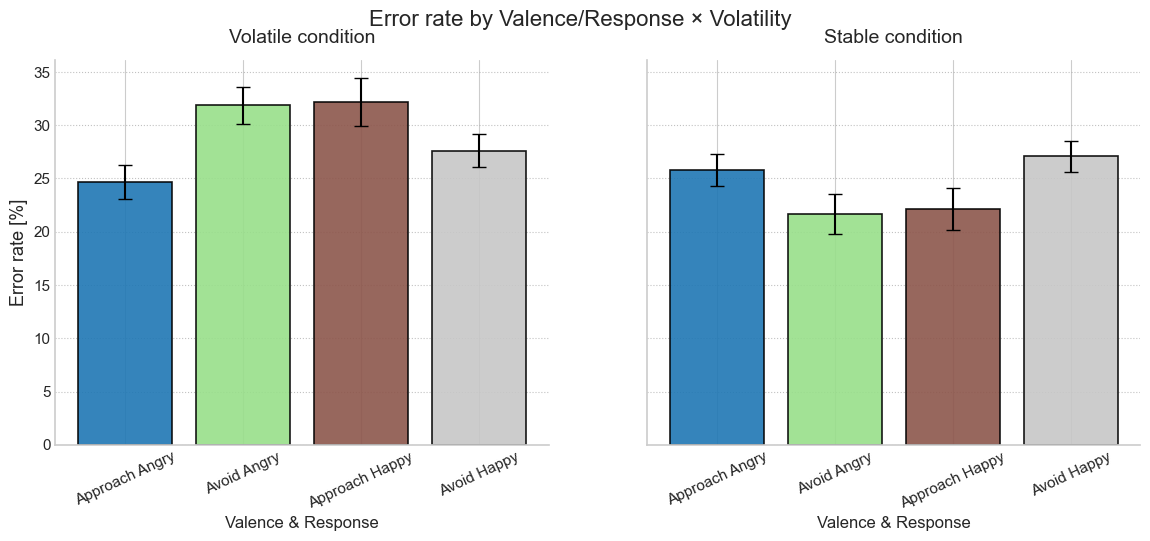

In [22]:
CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()
df["volatility"] = df["volatility"].astype(str).str.strip().str.lower()

# accuracy: prefer objectively_correct, fall back to *_boolean
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# compute error rate
df["error_rate"] = 1 - df["accuracy"]

# define condition labels (Approach/Avoid × Valence)
def make_label(row):
    resp = str(row["response"]).lower()
    val  = str(row["valence"]).lower()

    if resp.startswith("up"):
        act = "Approach"
    elif resp.startswith("down"):
        act = "Avoid"
    else:
        act = "Other"

    return f"{act} {val.capitalize()}"

df["condition"] = df.apply(make_label, axis=1)

# --- determine order dynamically ---
unique_conditions = df["condition"].unique().tolist()
preferred_order = [
    "Approach Angry", "Avoid Angry",
    "Approach Happy", "Avoid Happy"
]
order = [c for c in preferred_order if c in unique_conditions] + \
        [c for c in unique_conditions if c not in preferred_order]
print("Plotting order:", order)

# -------- per participant means incl. volatility --------
pp = (df.groupby(["participant", "volatility", "condition"])["error_rate"]
        .mean().mul(100).reset_index())

# -------- bar plots split by volatility --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# color palette
base_colors = {
    "Approach happy": "#4C78A8",   # blue
    "Avoid happy":    "#B279A2",   # magenta
    "Approach angry": "#59A14F",   # green
    "Avoid angry":    "#9C755F",   # brown
}
cmap = plt.get_cmap("tab20")

for ax, vol in zip(axes, ["volatile", "stable"]):
    sub = pp[pp["volatility"] == vol]

    # compute group stats
    means = sub.groupby("condition")["error_rate"].mean().reindex(order)
    sems  = sub.groupby("condition")["error_rate"].sem().reindex(order)

    # assign colors
    cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

    # plot bars
    ax.bar(order, means, yerr=sems,
           color=cols, capsize=5, alpha=0.9,
           edgecolor="black", linewidth=1.2)

    # cosmetics
    ax.set_title(f"{vol.capitalize()} condition", fontsize=14, pad=12)
    ax.set_xlabel("Valence & Response", fontsize=12)
    ax.tick_params(axis="x", labelrotation=25, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

axes[0].set_ylabel("Error rate [%]", fontsize=13)

fig.suptitle("Error rate by Valence/Response × Volatility", fontsize=16)
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_valence_response_barplot.pdf",
            dpi=300, facecolor="white", bbox_inches="tight")
plt.show()



Plotting order: ['Approach Angry', 'Avoid Angry', 'Approach Happy', 'Avoid Happy']


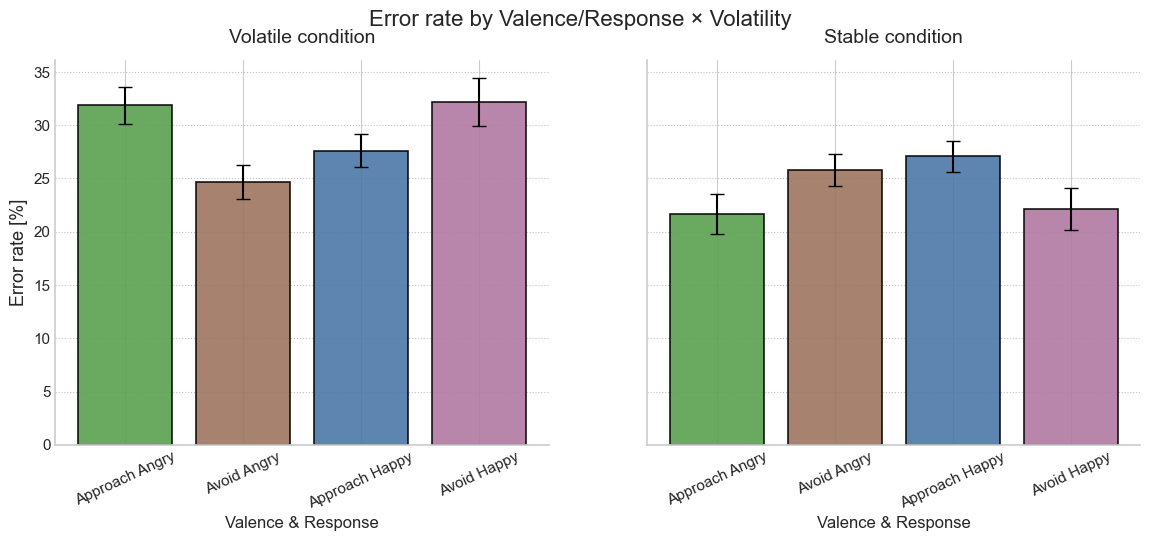

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()
df["volatility"] = df["volatility"].astype(str).str.strip().str.lower()

# accuracy: prefer objectively_correct, fall back to *_boolean
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# compute error rate
df["error_rate"] = 1 - df["accuracy"]

# define condition labels (Approach/Avoid × Valence)
def make_label(row):
    resp = str(row["response"]).lower()
    val  = str(row["valence"]).lower()

    if resp.startswith("down"):
        act = "Approach"
    elif resp.startswith("up"):
        act = "Avoid"
    else:
        act = "Other"

    return f"{act} {val.capitalize()}"

df["condition"] = df.apply(make_label, axis=1)

# --- determine order dynamically ---
unique_conditions = df["condition"].unique().tolist()
preferred_order = [
    
    "Approach Angry", "Avoid Angry",
    "Approach Happy", "Avoid Happy"
]
order = [c for c in preferred_order if c in unique_conditions] + \
        [c for c in unique_conditions if c not in preferred_order]
print("Plotting order:", order)

# -------- per participant means incl. volatility --------
pp = (df.groupby(["participant", "volatility", "condition"])["error_rate"]
        .mean().mul(100).reset_index())

# -------- bar plots split by volatility --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# color palette
base_colors = {
    "Approach Happy": "#4C78A8",   # blue
    "Avoid Happy":    "#B279A2",   # magenta
    "Approach Angry": "#59A14F",   # green
    "Avoid Angry":    "#9C755F",   # brown
}
cmap = plt.get_cmap("tab20")

for ax, vol in zip(axes, ["volatile", "stable"]):
    sub = pp[pp["volatility"] == vol]

    # compute group stats in preferred order
    means = sub.groupby("condition")["error_rate"].mean().reindex(order)
    sems  = sub.groupby("condition")["error_rate"].sem().reindex(order)

    # assign colors
    cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

    # plot bars with black outlines
    ax.bar(order, means, yerr=sems,
           color=cols, capsize=5, alpha=0.9,
           edgecolor="black", linewidth=1.2)

    # cosmetics
    ax.set_title(f"{vol.capitalize()} condition", fontsize=14, pad=12)
    ax.set_xlabel("Valence & Response", fontsize=12)
    ax.tick_params(axis="x", labelrotation=25, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

axes[0].set_ylabel("Error rate [%]", fontsize=13)

fig.suptitle("Error rate by Valence/Response × Volatility", fontsize=16)
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_valence_response_barplotf.pdf",
            dpi=300, facecolor="white", bbox_inches="tight")
plt.show()


Plotting order: ['Approach Angry', 'Avoid Angry', 'Approach Happy', 'Avoid Happy']


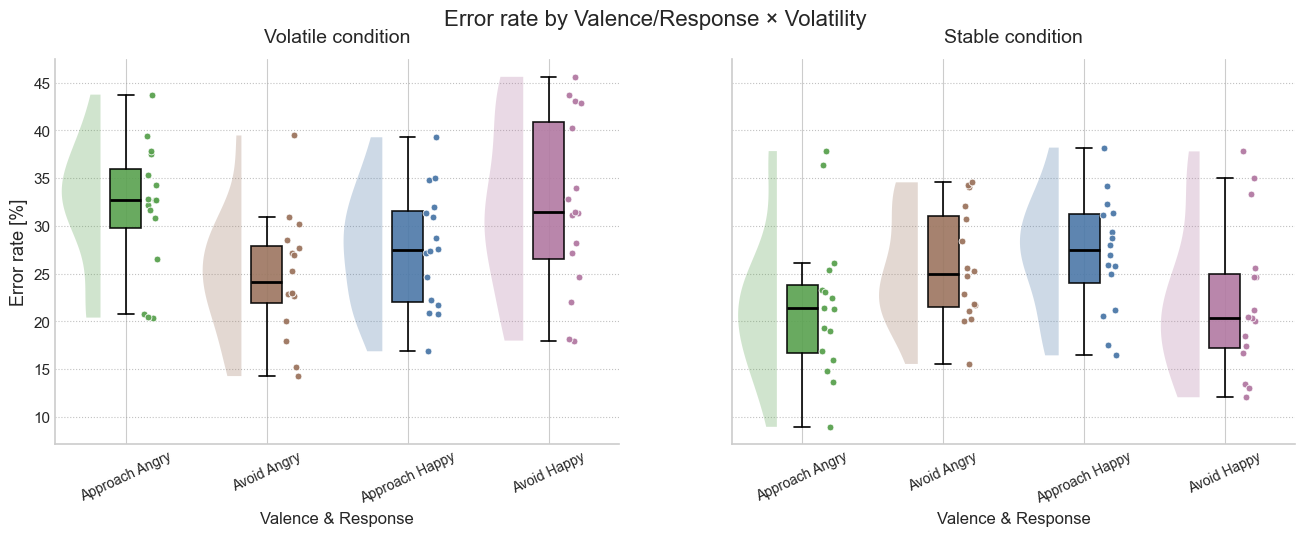

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()
df["volatility"] = df["volatility"].astype(str).str.strip().str.lower()

# accuracy: prefer objectively_correct, fall back to *_boolean
#acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
#if acc.isna().all():
  #  acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
#df["accuracy"] = acc
#df = df.dropna(subset=["accuracy"])

# compute error rate
df["error_rate"] = 1 - df["objectively_correct_boolean"]


# define condition labels (Approach/Avoid × Valence)
def make_label(row):
    resp = str(row["response"]).lower()
    val = str(row["valence"]).lower()

    if resp.startswith("down"):
        act = "Approach"
    elif resp.startswith("up"):
        act = "Avoid"
    else:
        act = "Other"

    return f"{act} {val.capitalize()}"


df["condition"] = df.apply(make_label, axis=1)

# --- determine order dynamically ---
unique_conditions = df["condition"].unique().tolist()
preferred_order = [
    "Approach Angry", "Avoid Angry",
    "Approach Happy", "Avoid Happy"
]
order = [c for c in preferred_order if c in unique_conditions] + \
        [c for c in unique_conditions if c not in preferred_order]
print("Plotting order:", order)

# -------- per participant means incl. volatility --------
pp = (df.groupby(["participant", "volatility", "condition"])["error_rate"]
      .mean().mul(100).reset_index())

# -------- violin/box/jitter plots split by volatility --------
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# color palette
base_colors = {
  
    "Approach Angry": "#59A14F",  # green
    "Avoid Angry": "#9C755F",  # brown
    "Approach Happy": "#4C78A8",  # blue
    "Avoid Happy": "#B279A2",  # magenta
}
cmap = plt.get_cmap("tab20")

rng = np.random.default_rng(7)

for ax, vol in zip(axes, ["volatile", "stable"]):
    sub = pp[pp["volatility"] == vol]

    # data per condition
    data = [sub[sub["condition"] == c]["error_rate"].dropna().values for c in order]
    nonempty = [len(a) > 0 for a in data]

    x = np.arange(len(order))
    violin_pos = x - 0.18
    box_pos = x
    scatter_pos = x + 0.18

    cols = [base_colors.get(c, cmap(i / len(order))) for i, c in enumerate(order)]

    # --- half violins (left) ---
    for i, (vals, ok) in enumerate(zip(data, nonempty)):
        if not ok:
            continue
        v = ax.violinplot([vals], positions=[violin_pos[i]], widths=0.55,
                          showextrema=False, side="low")
        body = v["bodies"][0]
        body.set_facecolor(cols[i])
        body.set_edgecolor("none")
        body.set_alpha(0.28)
        body.set_zorder(1)

    # --- boxes (center) with black outlines + black medians ---
    for i, (vals, ok) in enumerate(zip(data, nonempty)):
        if not ok:
            continue
        bx = ax.boxplot([vals], positions=[box_pos[i]], widths=0.22,
                        patch_artist=True, showfliers=False)
        for artist in bx["boxes"]:
            artist.set_facecolor(cols[i])
            artist.set_alpha(0.9)
            artist.set_edgecolor("black")  # black outline
            artist.set_linewidth(1.2)
        for part in ("whiskers", "caps"):
            for artist in bx[part]:
                artist.set_color("black")  # black whiskers/caps
                artist.set_linewidth(1.2)
        for artist in bx["medians"]:
            artist.set_color("black")  # black median
            artist.set_linewidth(2.0)

    # --- jittered participant means (right) ---
    for i, (vals, ok) in enumerate(zip(data, nonempty)):
        if not ok:
            continue
        jitter = (rng.random(len(vals)) - 0.5) * 0.10
        ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,
                   s=24, alpha=0.95, c=cols[i], edgecolors="white", linewidths=0.6, zorder=3)

    # cosmetics
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=25)
    ax.set_title(f"{vol.capitalize()} condition", fontsize=14, pad=12)
    ax.set_xlabel("Valence & Response", fontsize=12)
    ax.tick_params(axis="y", labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

axes[0].set_ylabel("Error rate [%]", fontsize=13)

fig.suptitle("Error rate by Valence/Response × Volatility", fontsize=16)
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_valence_response_by_volatility_violin.pdf",
            dpi=300, facecolor="white", bbox_inches="tight")
plt.show()


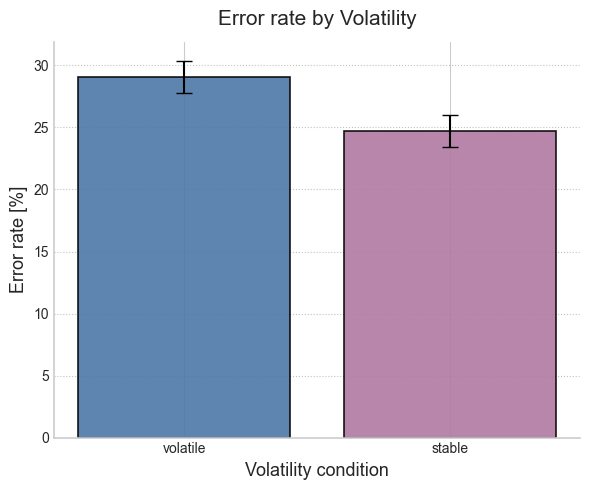

In [42]:
CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()
df["volatility"] = df["volatility"].astype(str).str.strip().str.lower()

# accuracy: prefer objectively_correct, fall back to *_boolean
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# compute error rate
df["error_rate"] = 1 - df["accuracy"]

# -------- per participant means by volatility --------
pp = (df.groupby(["participant", "volatility"])["error_rate"]
        .mean().mul(100).reset_index())

# -------- plot --------
fig, ax = plt.subplots(figsize=(6, 5))

vols = ["volatile", "stable"]
data = [pp[pp["volatility"] == v]["error_rate"].values for v in vols]

# simple bar plot with SEM
means = [d.mean() for d in data]
sems  = [d.std(ddof=1)/len(d)**0.5 for d in data]

ax.bar(vols, means, yerr=sems,
       color=["#4C78A8", "#B279A2"], capsize=6,
       edgecolor="black", linewidth=1.2, alpha=0.9)

ax.set_ylabel("Error rate [%]", fontsize=13)
ax.set_xlabel("Volatility condition", fontsize=13)
ax.set_title("Error rate by Volatility", fontsize=15, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_by_volatility.pdf",
            dpi=300, facecolor="white")
plt.show()


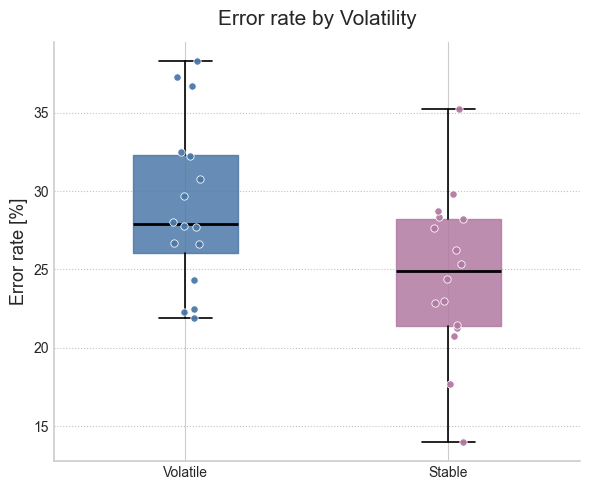

In [43]:
CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()
df["volatility"] = df["volatility"].astype(str).str.strip().str.lower()

# accuracy: prefer objectively_correct, fall back to *_boolean
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# compute error rate
df["error_rate"] = 1 - df["accuracy"]

# -------- per participant means by volatility --------
pp = (df.groupby(["participant", "volatility"])["error_rate"]
        .mean().mul(100).reset_index())

# -------- plot: box + jitter --------
fig, ax = plt.subplots(figsize=(6, 5))

vols = ["volatile", "stable"]
data = [pp[pp["volatility"] == v]["error_rate"].values for v in vols]

# colors
cols = ["#4C78A8", "#B279A2"]
x = np.arange(len(vols))

# --- boxplots ---
bx = ax.boxplot(data, positions=x, widths=0.4,
                patch_artist=True, showfliers=False)
for patch, col in zip(bx["boxes"], cols):
    patch.set_facecolor(col)
    patch.set_alpha(0.85)
    patch.set_edgecolor(col)
for part in ("whiskers", "caps", "medians"):
    for artist in bx[part]:
        artist.set_color("black")
        artist.set_linewidth(1.2 if part != "medians" else 2.0)

# --- jittered points ---
rng = np.random.default_rng(42)
for i, vals in enumerate(data):
    jitter = (rng.random(len(vals)) - 0.5) * 0.12
    ax.scatter(np.full_like(vals, x[i], dtype=float) + jitter, vals,
               s=28, alpha=0.95, c=cols[i], edgecolors="white", linewidths=0.6, zorder=3)

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels([v.capitalize() for v in vols])
ax.set_ylabel("Error rate [%]", fontsize=13)
ax.set_title("Error rate by Volatility", fontsize=15, pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrate_by_volatility_box.pdf",
            dpi=300, facecolor="white")
plt.show()


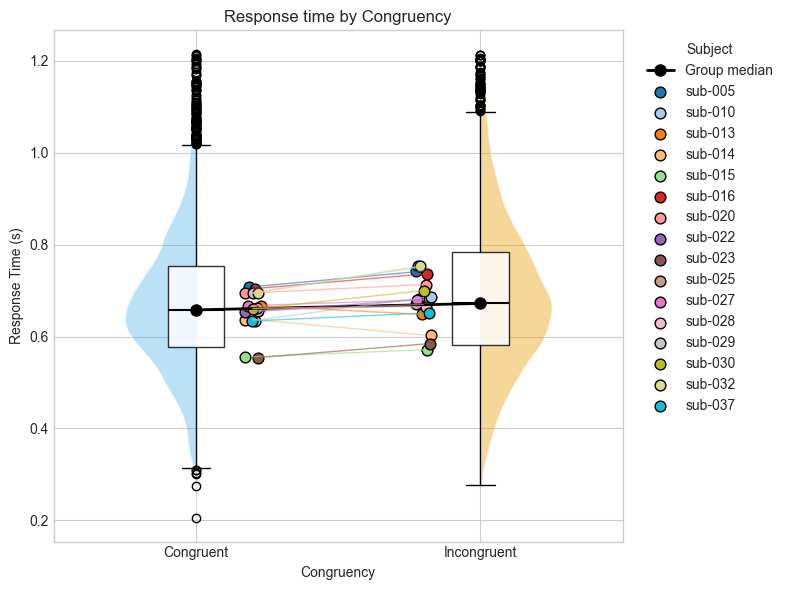

{'used_subject_col': 'subject_id', 'used_rt_col': 'rt_s', 'used_valence_col': 'valence', 'used_response_col': 'response', 'n_subjects': 16, 'n_rows': 9584}


In [17]:


# =============== CONFIG ===============
CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"  # <- use the file that has valence/response
SAVE_PATH = "/Users/carlacoca/Documents/master_internship/graphs/responsetimebyresponsecongruency.pdf"
MIN_RT = 0.2  # s
plt.style.use("seaborn-v0_8-whitegrid")
# ======================================

# ---- helpers ----
def pick(df, candidates, *, required=True):
    """Return the first existing column (after lowercase/strip)."""
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of the columns {candidates} found in CSV. Available: {list(df.columns)}")
    return None

# 0) Load + normalize column names
df = pd.read_csv(CSV_PATH, sep=";")
df.columns = df.columns.str.strip().str.lower()

# 0a) Align subject column (handles subject/participant/subject_id)
subj_col = pick(df, ["subject", "participant", "subject_id", "subj", "ppid", "id"])
if subj_col != "subject":
    df = df.rename(columns={subj_col: "subject"})

# 0b) RT column (handles rt_s/rt/response_time variants)
rt_col = pick(df, ["rt_s", "rt", "response_time_s", "response_time", "responsetime_s", "responsetime"])

# — FILTER OUT TOO-FAST RESPONSES —
df = df[pd.to_numeric(df[rt_col], errors="coerce") >= MIN_RT].copy()

# --- redefine congruency from valence × response when possible ---
valence_col  = pick(df, ["valence", "stim_valence", "emotion"], required=False)
response_col = pick(df, ["response", "resp", "button", "keypress", "key", "direction"], required=False)

if valence_col and response_col:
    df[valence_col]  = df[valence_col].astype(str).str.strip().str.lower()
    df[response_col] = df[response_col].astype(str).str.strip().str.lower()
    df["congruency"] = np.where(
        ((df[valence_col] == "happy") & (df[response_col] == "down")) |
        ((df[valence_col] == "angry") & (df[response_col] == "up")),
        "congruent", "incongruent"
    )
else:
    # Fallback to an existing congruency column if present
    cong_existing = pick(df, ["congruency", "congruency_response", "resp_congruency"], required=False)
    if not cong_existing:
        raise KeyError("Could not compute or find a congruency column. "
                       "Need valence+response OR an existing congruency field.")
    if cong_existing != "congruency":
        df = df.rename(columns={cong_existing: "congruency"})
    df["congruency"] = df["congruency"].astype(str).str.strip().str.lower()

# 1) Plot settings
conds = ["congruent", "incongruent"]
positions = [1, 2]  # x-positions for violins & group median
cb_colors = {
    "congruent":   "#56B4E9",  # sky blue
    "incongruent": "#E69F00",  # orange
}
jitter_centers = [1.2, 1.8]  # x-positions for subject points & connectors

subjects = sorted(df["subject"].unique())
cmap = plt.get_cmap("tab20")
colors = {subj: cmap(i / max(len(subjects), 1)) for i, subj in enumerate(subjects)}

# 2) Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# 3) Half-violins of the full RT distributions
all_data = [pd.to_numeric(df.loc[df["congruency"] == c, rt_col], errors="coerce").dropna().values for c in conds]
parts = ax.violinplot(all_data, positions=positions, showextrema=False)
for body, pos, cond in zip(parts["bodies"], positions, conds):
    verts = body.get_paths()[0].vertices
    if pos == 1:
        verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)  # left half
    else:
        verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)   # right half
    body.set_facecolor(cb_colors[cond])
    body.set_alpha(0.4)

# 4) Semi-transparent boxplots
ax.boxplot(
    all_data,
    positions=positions,
    widths=0.2,
    patch_artist=True,
    boxprops=dict(facecolor="white", edgecolor="k", alpha=0.8),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(markeredgecolor="black")
)

# 5) Group median line + points
group_medians = [np.median(d) if len(d) else np.nan for d in all_data]
ax.plot(positions, group_medians, marker="o", color="black", linestyle="-", linewidth=2, markersize=8, label="Group median")

# 6) Per-subject median RT per condition
med_rt = (
    df.groupby(["subject", "congruency"])[rt_col]
      .median()
      .unstack()
)

# 7) Per-subject connectors & points
for subj in subjects:
    if subj not in med_rt.index:
        continue
    y1 = med_rt.loc[subj].get("congruent", np.nan)
    y2 = med_rt.loc[subj].get("incongruent", np.nan)
    # skip if either missing
    if not np.isfinite(y1) or not np.isfinite(y2):
        continue

    ax.plot(jitter_centers, [y1, y2], color=colors[subj], alpha=0.6, linewidth=1)

    x1 = jitter_centers[0] + np.random.uniform(-0.03, 0.03)
    x2 = jitter_centers[1] + np.random.uniform(-0.03, 0.03)
    ax.scatter(x1, y1, color=colors[subj], s=60, edgecolor="k", label=subj)
    ax.scatter(x2, y2, color=colors[subj], s=60, edgecolor="k")

# 8) Final formatting
ax.set_xticks(positions)
ax.set_xticklabels([c.capitalize() for c in conds])
ax.set_ylabel("Response Time (s)")
ax.set_xlabel("Congruency")
ax.set_title("Response time by Congruency")
ax.legend(title="Subject", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
fig.savefig(SAVE_PATH, dpi=220)
plt.show()

# (Optional) Debug print so you can confirm what the script used:
print({
    "used_subject_col": subj_col,
    "used_rt_col": rt_col,
    "used_valence_col": valence_col,
    "used_response_col": response_col,
    "n_subjects": len(subjects),
    "n_rows": len(df),
})


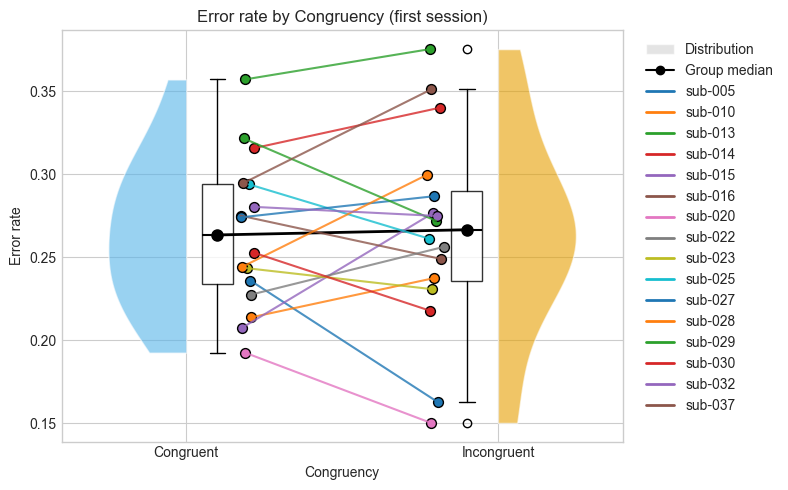

In [26]:

plt.style.use("seaborn-v0_8-whitegrid")

# 0) Load full data
df = pd.read_csv(
    "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv",
    sep=";"
)

# 🔹 Clean & normalize column names
df.columns = df.columns.str.strip().str.lower()

# 🔹 Standardize subject column
if "subject_id" in df.columns and "subject" not in df.columns:
    df = df.rename(columns={"subject_id": "subject"})

# 🔹 Define congruency from valence × response
df["valence"]  = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()

df["congruency"] = np.where(
    ((df["valence"] == "happy") & (df["response"] == "down")) |
    ((df["valence"] == "angry") & (df["response"] == "up")),
    "congruent",
    "incongruent"
)
# accuracy: prefer objectively_correct, fall back to *_boolean
acc = pd.to_numeric(df.get("objectively_correct"), errors="coerce")
if acc.isna().all():
    acc = pd.to_numeric(df.get("objectively_correct_boolean"), errors="coerce")
df["accuracy"] = acc
df = df.dropna(subset=["accuracy"])

# 🔹 compute error rate
df["error_rate"] = 1 - df["accuracy"]
# 🔹 Make sure error_rate is numeric
df["error_rate"] = pd.to_numeric(df["error_rate"], errors="coerce")

# 1) Find first session per subject
first_sessions = (
    df.groupby("subject")["session"]
      .min()
      .reset_index()
      .rename(columns={"session": "first_sess"})
)

# 2) Filter only first sessions
df = df.merge(first_sessions, on="subject")
df_first = df[df["session"] == df["first_sess"]]

# 3) Compute performance per subject × congruency (first session only)
perf_df = (
    df_first
    .groupby(["subject", "congruency"])["error_rate"]
    .mean()
    .reset_index(name="perf")
)

# 4) Plot setup
conds = ["congruent", "incongruent"]
positions = [1, 2]  # x-positions for violins & group median
cb_colors = {
    "congruent":   "#56B4E9",  # sky blue
    "incongruent": "#E69F00",  # orange
}
x_base   = [1, 2]
violin_x = [1, 2]      # Violin stays at base
box_x    = [1.1, 1.9]  # Shifted inward
jitter_x = [1.2, 1.8]  # Jitter for points

subjects = perf_df["subject"].unique()
cmap = plt.get_cmap("tab20")

fig, ax = plt.subplots(figsize=(8, 5))

# Half-violins
all_perf = [perf_df.loc[perf_df.congruency == c, "perf"].values for c in conds]
parts = ax.violinplot(all_perf, positions=violin_x, showextrema=False)
for body, x, cond in zip(parts["bodies"], violin_x, conds):
    verts = body.get_paths()[0].vertices
    if x == 1:
        verts[:, 0] = np.clip(verts[:, 0], -np.inf, x)
    else:
        verts[:, 0] = np.clip(verts[:, 0], x, np.inf)
    body.set_facecolor(cb_colors[cond])
    body.set_alpha(0.6)

# Boxplots
ax.boxplot(
    all_perf, positions=box_x, widths=0.1,
    patch_artist=True,
    boxprops=dict(facecolor="white", edgecolor="k", alpha=0.8),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(markeredgecolor="black")
)

# Group medians
group_meds = [np.median(a) for a in all_perf]
ax.plot(box_x, group_meds, marker="o", color="k", lw=2, ms=8, label="Group median")

# Define color map with special color for subject-020
subject_colors = [s for s in subjects if s != "subject-020"]
colors = {s: plt.get_cmap("tab10")(i % 10) for i, s in enumerate(subject_colors)}
colors["subject-020"] = "#d62728"  # highlight in red

# Per-subject connectors
for subj in sorted(subjects, key=lambda s: s != "subject-020"):
    row = perf_df[perf_df.subject == subj]
    y1 = row.loc[row.congruency == "congruent", "perf"].iloc[0]
    y2 = row.loc[row.congruency == "incongruent", "perf"].iloc[0]
    x1 = jitter_x[0] + np.random.uniform(-0.03, 0.03)
    x2 = jitter_x[1] + np.random.uniform(-0.03, 0.03)
    ax.plot([x1, x2], [y1, y2], color=colors[subj], alpha=0.8, lw=1.5)
    ax.scatter(x1, y1, color=colors[subj], edgecolor="k", s=50, label=subj)
    ax.scatter(x2, y2, color=colors[subj], edgecolor="k", s=50)

# Formatting
ax.set_xticks(x_base)
ax.set_xticklabels([c.capitalize() for c in conds])
ax.set_ylabel("Error rate")
ax.set_xlabel("Congruency")
ax.set_title("Error rate by Congruency (first session)")

# Legend
legend_elems = [
    Patch(facecolor="lightgray", label="Distribution", alpha=0.6),
    Line2D([0], [0], color="k", marker="o", label="Group median")
]
for subj in subjects:
    legend_elems.append(Line2D([0], [0], color=colors[subj], lw=2, label=subj))
ax.legend(handles=legend_elems, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/errorrateby_responsecongruency.pdf", dpi=220)
plt.show()


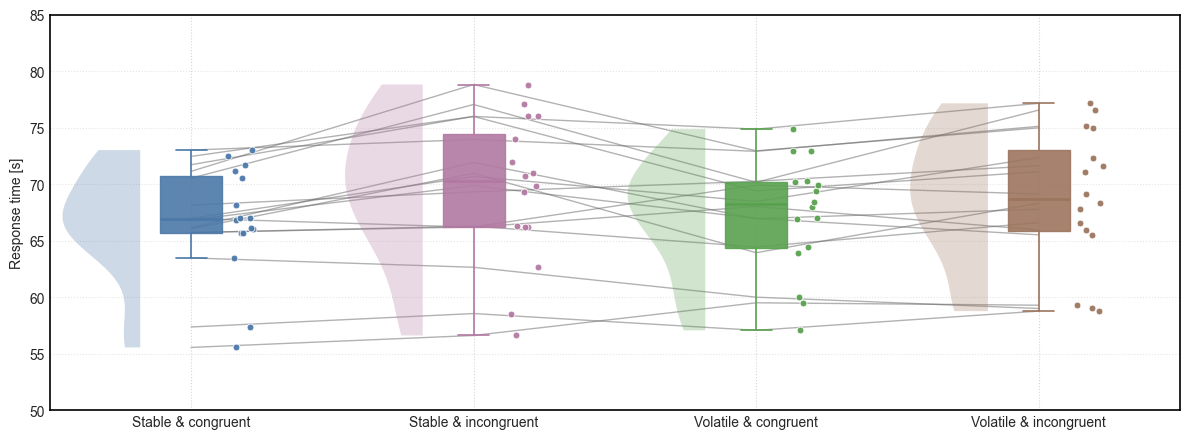

In [24]:
#This is the not innate congruency

# -*- coding: utf-8 -*-
# Bigger half-violin (left) + centered box + right jitter per condition
# Plotting ERROR RATE with new congruency definition


CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# --- redefine congruency based on valence × response ---
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()

df["congruency"] = np.where(
    ((df["valence"] == "happy") & (df["response"] == "down")) |
    ((df["valence"] == "angry") & (df["response"] == "up")),
    "congruent",
    "incongruent"
)

# volatility cleanup
df["volatility"] = (
    df["volatility"].astype(str).str.strip().str.lower()
    .map({"stable": "stable", "volatile": "volatile",
          "s": "stable", "v": "volatile", "0": "stable", "1": "volatile"})
)


df["condition"] = df["volatility"].str.title() + " & " + df["congruency"]
order = ["Stable & congruent", "Stable & incongruent", "Volatile & congruent", "Volatile & incongruent"]

# per-participant means (%)
pp = (df.groupby(["participant", "condition"])["RT_s"].mean().mul(100).reset_index())
wide = pp.pivot(index="participant", columns="condition", values="RT_s").reindex(columns=order)

# -------- plotting (bigger elements, still separated) --------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 4.5))

x = np.arange(len(order))
violin_pos = x - 0.18  # left
box_pos = x  # center
scatter_pos = x + 0.18  # right

data = [wide[c].dropna().values for c in order]
nonempty = [len(a) > 0 for a in data]

# supervisor-like palette
colors = {
    "Stable & congruent": "#4C78A8",  # blue
    "Stable & incongruent": "#B279A2",  # magenta
    "Volatile & congruent": "#59A14F",  # green
    "Volatile & incongruent": "#9C755F",  # brown
}
cols = [colors[c] for c in order]

# --- bigger half violins (left) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    v = ax.violinplot([vals], positions=[violin_pos[i]], widths=0.55,
                      showextrema=False, side='low')
    body = v["bodies"][0]
    body.set_facecolor(cols[i]);
    body.set_edgecolor("none");
    body.set_alpha(0.28);
    body.set_zorder(1)

# --- wider boxes (center) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    bx = ax.boxplot([vals], positions=[box_pos[i]], widths=0.22,
                    patch_artist=True, showfliers=False)
    # color all parts
    for artist in bx["boxes"]:
        artist.set_facecolor(cols[i]);
        artist.set_alpha(0.90);
        artist.set_edgecolor(cols[i])
    for part in ("whiskers", "caps", "medians"):
        for artist in bx[part]:
            artist.set_color(cols[i])
            artist.set_linewidth(1.2 if part != "medians" else 2.0)

# --- jittered participant means (right) ---
rng = np.random.default_rng(7)
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    jitter = (rng.random(len(vals)) - 0.5) * 0.10
    ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,
               s=24, alpha=0.95, c=cols[i], edgecolors="white", linewidths=0.6, zorder=3)

# --- within-subject lines (behind) ---
for _, row in wide.iterrows():
    y = row.values.astype(float)
    xs = x[~np.isnan(y)]
    ys = y[~np.isnan(y)]
    if len(xs) >= 2:
        #ax.plot(xs, ys, linewidth=0.6, alpha=0.20, color="#c9c9c9", zorder=0)
        # within-subject lines (behind)
        ax.plot(xs, ys, linewidth=1.0, alpha=0.5, color="#666666", zorder=0)

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Response time [s]")  # 🔹 updated label
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)
# Stronger gridlines
ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.8)  # darker gray
ax.grid(axis="x", linestyle=":", color="#bbbbbb", alpha=0.6)  # optional x grid

vals = np.concatenate([a for a in data if len(a) > 0]) if any(nonempty) else np.array([0, 100])
lo = max(0, np.floor(vals.min() / 5) * 5 - 5)
hi = min(100, np.ceil(vals.max() / 5) * 5 + 5)
if lo >= hi: lo, hi = 0, 100
ax.set_ylim(lo, hi)
ax.grid(axis="y", linestyle=":", alpha=0.25)
ax.margins(x=0.02)
fig.tight_layout()
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
fig.savefig(
    "/Users/carlacoca/Documents/master_internship/graphs/hypothesis2_RTscongruency.pdf",
    dpi=220,
    facecolor="white"
)

plt.show()

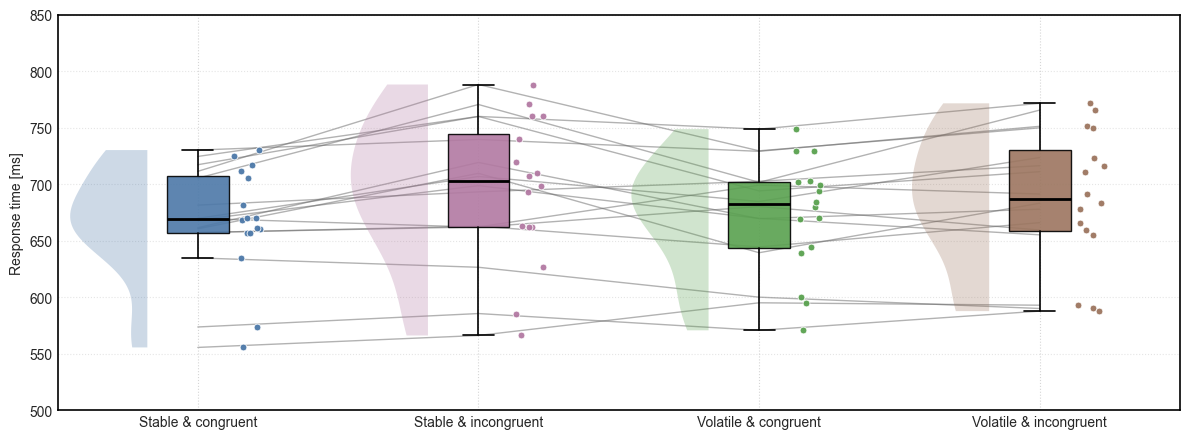

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# --- redefine congruency based on valence × response ---
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()

df["congruency"] = np.where(
    ((df["valence"] == "happy") & (df["response"] == "down")) |
    ((df["valence"] == "angry") & (df["response"] == "up")),
    "congruent",
    "incongruent"
)

# volatility cleanup
df["volatility"] = (
    df["volatility"].astype(str).str.strip().str.lower()
    .map({"stable": "stable", "volatile": "volatile",
          "s": "stable", "v": "volatile", "0": "stable", "1": "volatile"})
)

df["condition"] = df["volatility"].str.title() + " & " + df["congruency"]
order = ["Stable & congruent", "Stable & incongruent", "Volatile & congruent", "Volatile & incongruent"]

# per-participant means (%)

pp = (df.groupby(["participant", "condition"])["RT_s"].mean().mul(1000).reset_index())

wide = pp.pivot(index="participant", columns="condition", values="RT_s").reindex(columns=order)

# -------- plotting (bigger elements, still separated) --------
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 4.5))

x = np.arange(len(order))
violin_pos = x - 0.18  # left
box_pos = x  # center
scatter_pos = x + 0.18  # right

data = [wide[c].dropna().values for c in order]
nonempty = [len(a) > 0 for a in data]

# supervisor-like palette
colors = {
    "Stable & congruent": "#4C78A8",  # blue
    "Stable & incongruent": "#B279A2",  # magenta
    "Volatile & congruent": "#59A14F",  # green
    "Volatile & incongruent": "#9C755F",  # brown
}
cols = [colors[c] for c in order]

# --- bigger half violins (left) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    v = ax.violinplot([vals], positions=[violin_pos[i]], widths=0.55,
                      showextrema=False, side='low')
    body = v["bodies"][0]
    body.set_facecolor(cols[i])
    body.set_edgecolor("none")
    body.set_alpha(0.28)
    body.set_zorder(1)

# --- wider boxes (center) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    bx = ax.boxplot([vals], positions=[box_pos[i]], widths=0.22,
                    patch_artist=True, showfliers=False)
    # fill color
    for artist in bx["boxes"]:
        artist.set_facecolor(cols[i])
        artist.set_alpha(0.90)
        artist.set_edgecolor("black")   # 🔹 black outline
    
    # whiskers + caps
    for part in ("whiskers", "caps"):
        for artist in bx[part]:
            artist.set_color("black")   # 🔹 black whiskers/caps
            artist.set_linewidth(1.2)
    
    # median line
    for artist in bx["medians"]:
        artist.set_color("black")       # 🔹 black median
        artist.set_linewidth(2.0)

# --- jittered participant means (right) ---
rng = np.random.default_rng(7)
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    jitter = (rng.random(len(vals)) - 0.5) * 0.10
    ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,
               s=24, alpha=0.95, c=cols[i], edgecolors="white", linewidths=0.6, zorder=3)

# --- within-subject lines (behind) ---
for _, row in wide.iterrows():
    y = row.values.astype(float)
    xs = x[~np.isnan(y)]
    ys = y[~np.isnan(y)]
    if len(xs) >= 2:
        ax.plot(xs, ys, linewidth=1.0, alpha=0.5, color="#666666", zorder=0)

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Response time [ms]")  # 🔹 updated label
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)
# Stronger gridlines
ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.8)  # darker gray
ax.grid(axis="x", linestyle=":", color="#bbbbbb", alpha=0.6)  # optional x grid

# --- fixed y-axis scale ---
ax.set_ylim(500, 850)   # 🔹 fixed to ms scale

ax.grid(axis="y", linestyle=":", alpha=0.25)
ax.margins(x=0.02)
fig.tight_layout()
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
fig.savefig(
    "/Users/carlacoca/Documents/master_internship/graphs/hypothesis2_RTscongruency.pdf",
    dpi=220,
    facecolor="white"
)

plt.show()


Plotting order: ['Approach Angry', 'Avoid Angry', 'Approach Happy', 'Avoid Happy']


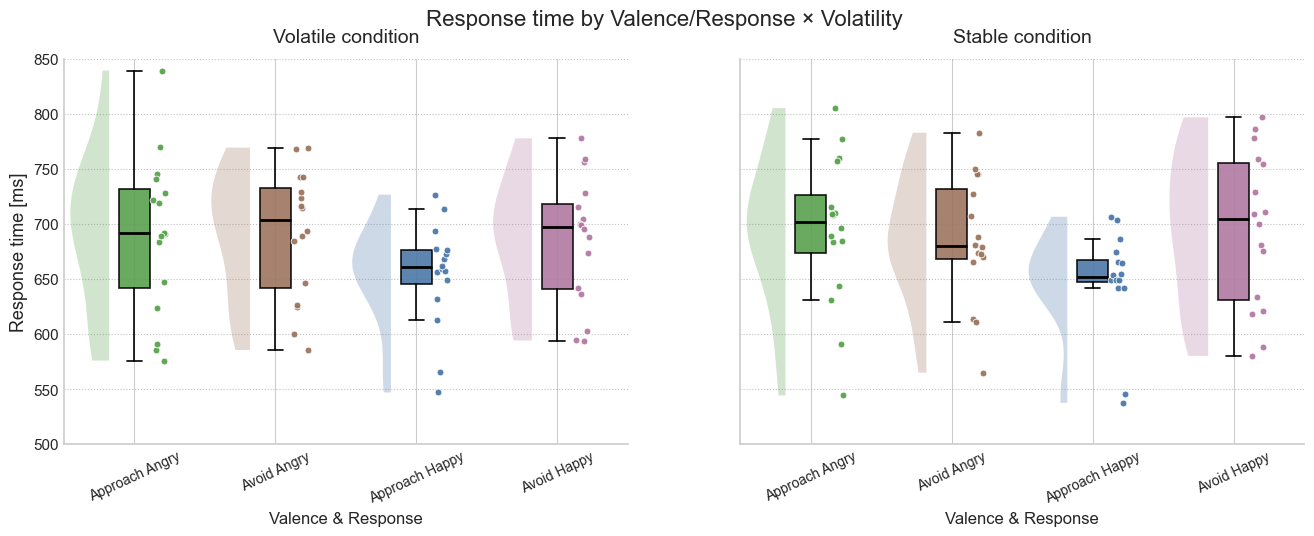

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()
df["volatility"] = df["volatility"].astype(str).str.strip().str.lower()

# define condition labels (Approach/Avoid × Valence)
def make_label(row):
    resp = str(row["response"]).lower()
    val = str(row["valence"]).lower()

    if resp.startswith("down"):
        act = "Approach"
    elif resp.startswith("up"):
        act = "Avoid"
    else:
        act = "Other"

    return f"{act} {val.capitalize()}"

df["condition"] = df.apply(make_label, axis=1)

# --- determine order dynamically ---
unique_conditions = df["condition"].unique().tolist()
preferred_order = [
    "Approach Angry", "Avoid Angry",
    "Approach Happy", "Avoid Happy"
]
order = [c for c in preferred_order if c in unique_conditions] + \
        [c for c in unique_conditions if c not in preferred_order]
print("Plotting order:", order)

# -------- per participant means (RT in ms) --------
pp = (df.groupby(["participant", "volatility", "condition"])["RT_s"]
      .mean().mul(1000).reset_index())  # convert s → ms

# -------- violin/box/jitter plots split by volatility --------
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# color palette
base_colors = {
    "Approach Angry": "#59A14F",   # green
    "Avoid Angry": "#9C755F",      # brown
    "Approach Happy": "#4C78A8",   # blue
    "Avoid Happy": "#B279A2",      # magenta
}
cmap = plt.get_cmap("tab20")

rng = np.random.default_rng(7)

for ax, vol in zip(axes, ["volatile", "stable"]):
    sub = pp[pp["volatility"] == vol]

    # data per condition
    data = [sub[sub["condition"] == c]["RT_s"].dropna().values for c in order]
    nonempty = [len(a) > 0 for a in data]

    x = np.arange(len(order))
    violin_pos = x - 0.18
    box_pos = x
    scatter_pos = x + 0.18

    cols = [base_colors.get(c, cmap(i / len(order))) for i, c in enumerate(order)]

    # --- half violins (left) ---
    for i, (vals, ok) in enumerate(zip(data, nonempty)):
        if not ok:
            continue
        v = ax.violinplot([vals], positions=[violin_pos[i]], widths=0.55,
                          showextrema=False, side="low")
        body = v["bodies"][0]
        body.set_facecolor(cols[i])
        body.set_edgecolor("none")
        body.set_alpha(0.28)
        body.set_zorder(1)

    # --- boxes (center) with black outlines + black medians ---
    for i, (vals, ok) in enumerate(zip(data, nonempty)):
        if not ok:
            continue
        bx = ax.boxplot([vals], positions=[box_pos[i]], widths=0.22,
                        patch_artist=True, showfliers=False)
        for artist in bx["boxes"]:
            artist.set_facecolor(cols[i])
            artist.set_alpha(0.9)
            artist.set_edgecolor("black")  # black outline
            artist.set_linewidth(1.2)
        for part in ("whiskers", "caps"):
            for artist in bx[part]:
                artist.set_color("black")  # black whiskers/caps
                artist.set_linewidth(1.2)
        for artist in bx["medians"]:
            artist.set_color("black")  # black median
            artist.set_linewidth(2.0)

    # --- jittered participant means (right) ---
    for i, (vals, ok) in enumerate(zip(data, nonempty)):
        if not ok:
            continue
        jitter = (rng.random(len(vals)) - 0.5) * 0.10
        ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,
                   s=24, alpha=0.95, c=cols[i], edgecolors="white", linewidths=0.6, zorder=3)

    # cosmetics
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=25)
    ax.set_title(f"{vol.capitalize()} condition", fontsize=14, pad=12)
    ax.set_xlabel("Valence & Response", fontsize=12)
    ax.tick_params(axis="y", labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

    # --- y-axis window 400–800 ms ---
    ax.set_ylim(500, 850)

axes[0].set_ylabel("Response time [ms]", fontsize=13)

fig.suptitle("Response time by Valence/Response × Volatility", fontsize=16)
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/RTs_valence_response_by_volatility_violin.pdf",
            dpi=300, facecolor="white", bbox_inches="tight")
plt.show()


Plotting order: ['Approach Angry', 'Avoid Angry', 'Approach Happy', 'Avoid Happy']


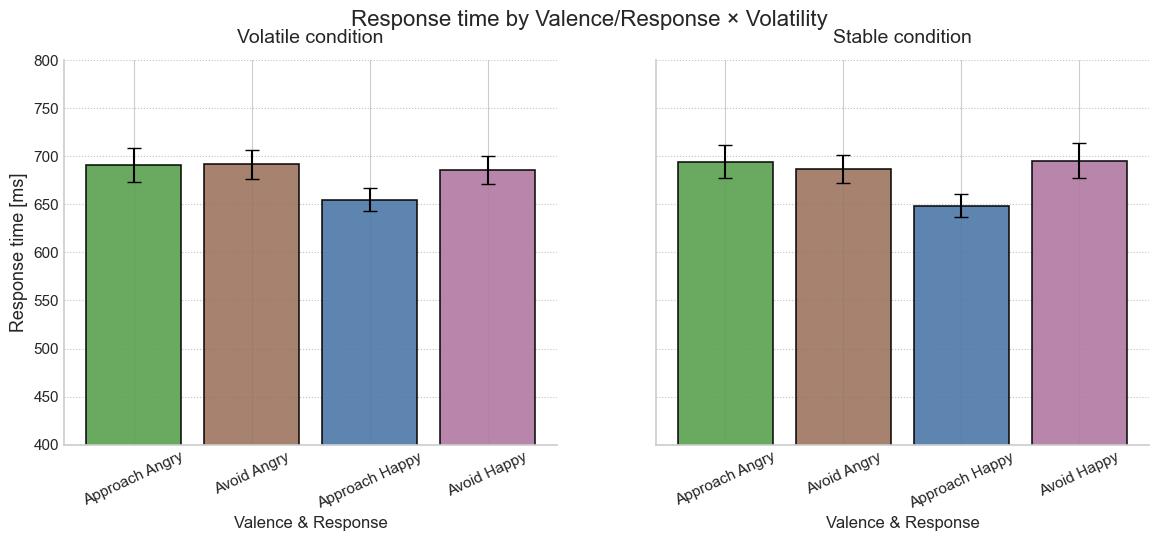

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()
df["volatility"] = df["volatility"].astype(str).str.strip().str.lower()

# define condition labels (Approach/Avoid × Valence)
def make_label(row):
    resp = str(row["response"]).lower()
    val  = str(row["valence"]).lower()

    if resp.startswith("down"):
        act = "Approach"
    elif resp.startswith("up"):
        act = "Avoid"
    else:
        act = "Other"

    return f"{act} {val.capitalize()}"

df["condition"] = df.apply(make_label, axis=1)

# --- determine order dynamically ---
unique_conditions = df["condition"].unique().tolist()
preferred_order = [
    "Approach Angry", "Avoid Angry",
    "Approach Happy", "Avoid Happy"
]
order = [c for c in preferred_order if c in unique_conditions] + \
        [c for c in unique_conditions if c not in preferred_order]
print("Plotting order:", order)

# -------- per participant means incl. volatility (RT in ms) --------
pp = (df.groupby(["participant", "volatility", "condition"])["RT_s"]
        .mean().mul(1000).reset_index())  # convert s → ms

# -------- bar plots split by volatility --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# color palette
base_colors = {
    "Approach Happy": "#4C78A8",   # blue
    "Avoid Happy":    "#B279A2",   # magenta
    "Approach Angry": "#59A14F",   # green
    "Avoid Angry":    "#9C755F",   # brown
}
cmap = plt.get_cmap("tab20")

for ax, vol in zip(axes, ["volatile", "stable"]):
    sub = pp[pp["volatility"] == vol]

    # compute group stats in preferred order
    means = sub.groupby("condition")["RT_s"].mean().reindex(order)
    sems  = sub.groupby("condition")["RT_s"].sem().reindex(order)

    # assign colors
    cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

    # plot bars with black outlines
    ax.bar(order, means, yerr=sems,
           color=cols, capsize=5, alpha=0.9,
           edgecolor="black", linewidth=1.2)

    # cosmetics
    ax.set_title(f"{vol.capitalize()} condition", fontsize=14, pad=12)
    ax.set_xlabel("Valence & Response", fontsize=12)
    ax.tick_params(axis="x", labelrotation=25, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

    # y-axis window 400–800 ms
    ax.set_ylim(400, 800)

axes[0].set_ylabel("Response time [ms]", fontsize=13)

fig.suptitle("Response time by Valence/Response × Volatility", fontsize=16)
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/RTs_valence_response_barplot.pdf",
            dpi=300, facecolor="white", bbox_inches="tight")
plt.show()


Plotting order: ['Approach Angry', 'Avoid Angry', 'Approach Happy', 'Avoid Happy']


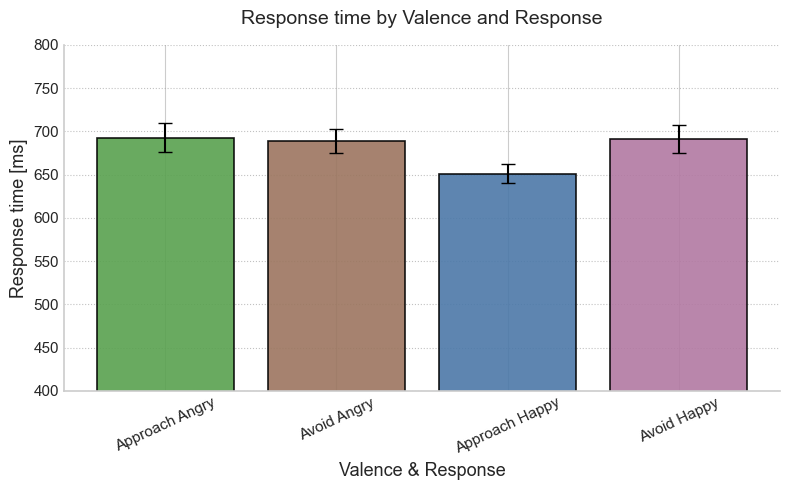

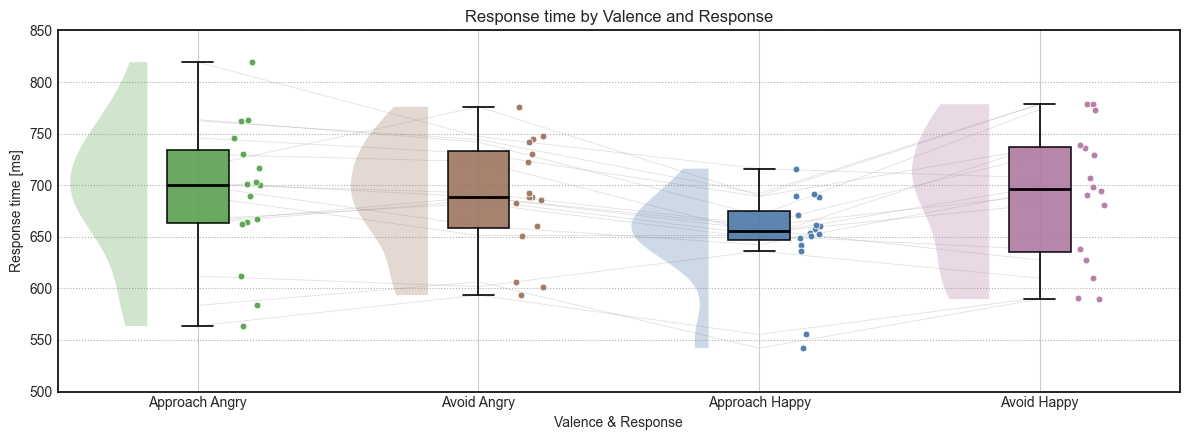

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/Volumes/project/3025011.02/for_carla/combined_results_kenneth.csv"

# -------- load & prep --------
df = pd.read_csv(CSV_PATH, sep=";")
df = df.rename(columns={"subject_id": "participant"})

# clean fields
df["valence"] = df["valence"].astype(str).str.strip().str.lower()
df["response"] = df["response"].astype(str).str.strip().str.lower()

# define condition labels (kept as you had them)
def make_label(row):
    resp = str(row["response"]).lower()
    val  = str(row["valence"]).lower()

    if resp.startswith("down"):
        act = "Approach"
    elif resp.startswith("up"):
        act = "Avoid"
    else:
        act = "Other"

    return f"{act} {val.capitalize()}"

df["condition"] = df.apply(make_label, axis=1)

# --- determine order dynamically ---
unique_conditions = df["condition"].unique().tolist()

preferred_order = [
    "Approach Angry", "Avoid Angry",
    "Approach Happy", "Avoid Happy"
]

order = [c for c in preferred_order if c in unique_conditions] + \
        [c for c in unique_conditions if c not in preferred_order]
print("Plotting order:", order)

# per-participant means (RT in ms)
pp = (df.groupby(["participant", "condition"])["RT_s"]
        .mean().mul(1000).reset_index())  # convert s → ms
wide = pp.pivot(index="participant", columns="condition", values="RT_s").reindex(columns=order)

# ===========================
# -------- BAR PLOT ---------
# ===========================
fig, ax = plt.subplots(figsize=(8, 5))

# compute group mean + SEM
means = wide.mean(axis=0, skipna=True)
sems  = wide.sem(axis=0, skipna=True)

# palette
base_colors = {
    "Approach Happy": "#4C78A8",   # blue
    "Avoid Happy":    "#B279A2",   # magenta
    "Approach Angry": "#59A14F",   # green
    "Avoid Angry":    "#9C755F",   # brown
}
cmap = plt.get_cmap("tab20")
cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

# plot bars with black outlines
ax.bar(order, means, yerr=sems,
       color=cols, capsize=5, alpha=0.9,
       edgecolor="black", linewidth=1.2)

# cosmetics
ax.set_ylabel("Response time [ms]", fontsize=13)
ax.set_xlabel("Valence & Response", fontsize=13)
ax.set_title("Response time by Valence and Response", fontsize=14, pad=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.tick_params(axis="x", labelrotation=25, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.6)

# y-axis window 400–800 ms
ax.set_ylim(400, 800)

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/RTs_valence_response_bar.pdf",
            dpi=300, facecolor="white")
plt.show()

# ===============================
# --- VIOLIN + BOX + SCATTER ----
# ===============================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 4.5))

x = np.arange(len(order))
violin_pos  = x - 0.18
box_pos     = x
scatter_pos = x + 0.18

data = [wide[c].dropna().values for c in order]
nonempty = [len(a) > 0 for a in data]

# palette (fallback if condition not in dict)
cols = [base_colors.get(c, cmap(i/len(order))) for i, c in enumerate(order)]

# --- half violins (left) ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    v = ax.violinplot([vals], positions=[violin_pos[i]], widths=0.55,
                      showextrema=False, side='low')
    body = v["bodies"][0]
    body.set_facecolor(cols[i])
    body.set_edgecolor("none")
    body.set_alpha(0.28)
    body.set_zorder(1)

# --- boxes (center) with black outlines + black medians ---
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    bx = ax.boxplot([vals], positions=[box_pos[i]], widths=0.22,
                    patch_artist=True, showfliers=False)
    for artist in bx["boxes"]:
        artist.set_facecolor(cols[i])
        artist.set_alpha(0.90)
        artist.set_edgecolor("black")
        artist.set_linewidth(1.2)
    for part in ("whiskers", "caps"):
        for artist in bx[part]:
            artist.set_color("black")
            artist.set_linewidth(1.2)
    for artist in bx["medians"]:
        artist.set_color("black")
        artist.set_linewidth(2.0)

# --- jittered participant means (right) ---
rng = np.random.default_rng(7)
for i, (vals, ok) in enumerate(zip(data, nonempty)):
    if not ok:
        continue
    jitter = (rng.random(len(vals)) - 0.5) * 0.10
    ax.scatter(np.full_like(vals, scatter_pos[i], dtype=float) + jitter, vals,
               s=24, alpha=0.95, c=cols[i],
               edgecolors="white", linewidths=0.6, zorder=3)

# --- within-subject lines ---
for _, row in wide.iterrows():
    y = row.values.astype(float)
    xs = x[~np.isnan(y)]
    ys = y[~np.isnan(y)]
    if len(xs) >= 2:
        ax.plot(xs, ys, linewidth=0.6, alpha=0.25, color="#888888", zorder=0)

# cosmetics
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Response time [ms]")
ax.set_xlabel("Valence & Response")
ax.set_title("Response time by Valence and Response")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.2)

ax.grid(axis="y", linestyle=":", color="#999999", alpha=0.8)

# y-axis window 400–800 ms
ax.set_ylim(500, 850)

fig.tight_layout()
fig.savefig("/Users/carlacoca/Documents/master_internship/graphs/RTs_valence_response_violin.pdf",
            dpi=220, facecolor="white")
plt.show()
